In [312]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [313]:
main_df = pd.read_excel("Inventory-Tracking.xlsx")
df = main_df.copy()

In [314]:
print(f"Shape : {df.shape}")

Shape : (500, 9)


In [315]:
print(f"\nis null value :\n{df.isna().sum()}")


is null value :
ProductID          0
ProductName        0
QuantityInStock    0
ReorderPoint       0
Supplier           0
SupplierContact    0
LeadTime           0
StorageLocation    0
UnitCost           0
dtype: int64


In [316]:
df.duplicated().sum()

np.int64(0)

In [317]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 9 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   ProductID        500 non-null    str    
 1   ProductName      500 non-null    str    
 2   QuantityInStock  500 non-null    int64  
 3   ReorderPoint     500 non-null    int64  
 4   Supplier         500 non-null    str    
 5   SupplierContact  500 non-null    str    
 6   LeadTime         500 non-null    int64  
 7   StorageLocation  500 non-null    str    
 8   UnitCost         500 non-null    float64
dtypes: float64(1), int64(3), str(5)
memory usage: 35.3 KB


In [318]:
# Shows top 5 rows
df.head()

,ProductID,ProductName,QuantityInStock,ReorderPoint,Supplier,SupplierContact,LeadTime,StorageLocation,UnitCost
0,P98420,Monitor,97,81,Global Parts,global parts@example.com,17,WH-5,174.13
1,P70372,Monitor,229,32,SupplyCo,supplyco@example.com,19,WH-4,91.07
2,P54851,Laptop,15,72,Global Parts,global parts@example.com,13,WH-5,179.93
3,P89338,Tablet,35,56,Global Parts,global parts@example.com,21,WH-2,159.55
4,P76449,Chair,442,64,DirectGoods,directgoods@example.com,8,WH-4,2.02


In [319]:
# shows random 5 rows
df.sample(5)

,ProductID,ProductName,QuantityInStock,ReorderPoint,Supplier,SupplierContact,LeadTime,StorageLocation,UnitCost
116,P27939,Laptop,83,58,WarePlus,wareplus@example.com,6,WH-3,75.91
478,P36445,Chair,345,60,Global Parts,global parts@example.com,12,WH-3,73.89
360,P71902,Desk,32,20,WarePlus,wareplus@example.com,6,WH-2,148.51
256,P10033,Monitor,358,96,WarePlus,wareplus@example.com,19,WH-1,120.24
254,P92241,Chair,419,23,Global Parts,global parts@example.com,5,WH-2,67.05


### Findings ###

    No missing values, no duplicate rows.
    7 products across 5 warehouses (WH-1 to WH-5).
    Each product is carried by all 4 suppliers, and each supplier
    carries all 7 products — the supplier base is evenly spread.

    Stock by product (total across all warehouses):
    - Highest: Chair (19,585), Phone (19,421), Monitor (19,063)
    - Lowest: Desk (15,155), Printer (16,692), Tablet (17,650)

    66 products (out of 500) are below their reorder point.
    373 products are overstocked (shortfall < -50), meaning stock is
    running well above what's actually needed — overstocking is a far
    bigger issue in this data than understocking.

    Every product is overstocked in all 5 warehouses (no product/warehouse
    combination escapes it), pointing to a systemic over-ordering pattern
    rather than a one-off issue with a specific item or location.

    Overstock rate by warehouse (count of overstocked products):
    - WH-3: 82 (highest)
    - WH-1: 78
    - WH-4: 76
    - WH-2: 73
    - WH-5: 64 (lowest)

    Low-stock rate by warehouse (share of products below reorder point):
    - WH-2: 15.84% (highest)
    - WH-1: 15.60%
    - WH-5: 14.12%
    - WH-4: 10.53%
    - WH-3: 10.00% (lowest)

    Note: WH-3 has the most overstocking but the least understocking,
    and WH-5 is close to the reverse — these two issues don't
    necessarily happen in the same place.

    Supplier shortage events (how often each supplier's products
    ran below reorder point):
    - Global Parts: 20 (highest)
    - DirectGoods: 17
    - WarePlus: 15
    - SupplyCo: 14 (lowest)

    Supplier average lead time:
    - Fastest: SupplyCo (11.3 days)
    - Slowest: WarePlus (12.9 days)

    Lead time vs shortfall: essentially no correlation (r = -0.10) -
    longer lead times don't reliably produce bigger shortfalls.
    Unit cost vs shortfall: essentially no correlation either (r = 0.06) -
    shortfalls are spread fairly evenly across price points.

***Questions***

    products names
    product count
    high stock product
    low stock product 
    total wherehouse we have
    products in every WH with count
    is QuantityInStock <= ReorderPoint product count with reoder value of the product show ReorderPoint-QuantityInStock

    is QuantityInStock <= ReorderPoint set alert
    what is diference  QuantityInStock and ReorderPoint	
    for each product how many supplier 
    for each supplier how many product 
    which supplier has low lead time
    which supplier has high lead time


    which warehouse has more overstocks 
    which warehouse has which product is overstock 
    which product is overstock in 3 or more wh
    a specific product stock report in all wh 

## Development Notes

AI tools were used during this project for:

- debugging pandas code
- improving visualization design
- exploring inventory analysis approaches
- learning better coding practices

All business logic, analysis decisions, and final implementation understanding were reviewed.

***Descriptive Analysis***

In [320]:
# Checking if productid(primary key) repeate or not 
df['ProductID'].value_counts()

ProductID
P98420    1
P70372    1
P54851    1
P89338    1
P76449    1
         ..
P61528    1
P25204    1
P11509    1
P76776    1
P19859    1
Name: count, Length: 500, dtype: int64

In [321]:
# products names
product_names = df["ProductName"].unique().tolist()
print(f'{len(product_names)} products we have: \n{product_names}')

7 products we have: 
['Monitor', 'Laptop', 'Tablet', 'Chair', 'Printer', 'Desk', 'Phone']


In [322]:
# count of wh and name
total_werehouse = sorted(df["StorageLocation"].unique().tolist())
print(f'{len(total_werehouse)} warehouses we have: \n{total_werehouse}')

5 warehouses we have: 
['WH-1', 'WH-2', 'WH-3', 'WH-4', 'WH-5']


We have a total of 7 products available.

Product Name                   | Quantity  
---------------------------------------------
Chair                         |19585
---------------------------------------------
Phone                         |19421
---------------------------------------------
Monitor                       |19063
---------------------------------------------
Laptop                        |18275
---------------------------------------------
Tablet                        |17650
---------------------------------------------
Printer                       |16692
---------------------------------------------
Desk                          |15155
---------------------------------------------


Text(0, 0.5, 'Available Stocks')

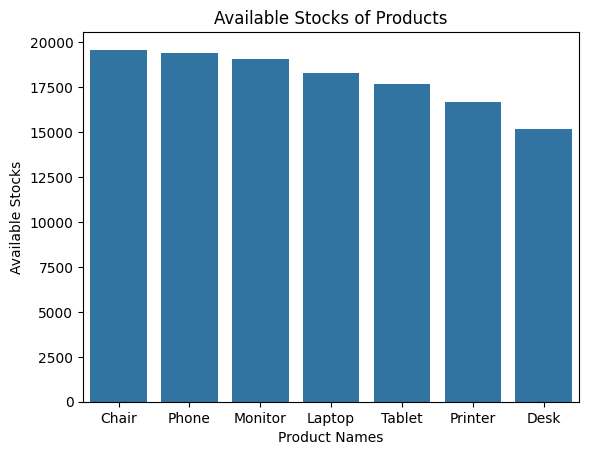

In [323]:
# Check Quantitys of each product
Stock_Available = df.groupby("ProductName")["QuantityInStock"].sum().sort_values(ascending=False)

print(f"We have a total of {len(Stock_Available)} products available.\n")
print(f"{'Product Name':<30} | {'Quantity':<10}")
print("-" * 45)

for idx,val in Stock_Available.items() :
    print(f"{idx:<30}|{val:>}")
    print("-" * 45)

sns.barplot(Stock_Available)
plt.title("Available Stocks of Products")
plt.xlabel("Product Names")
plt.ylabel("Available Stocks")


In [324]:
# top3 products with highest stock in wh
top3 = Stock_Available.nlargest(3)
print("top 3 products in stock\n",top3)
print(type(Stock_Available))
# print(f" top 1 product with highest quantity : {Stock_Available[0]}")


top 3 products in stock
 ProductName
Chair      19585
Phone      19421
Monitor    19063
Name: QuantityInStock, dtype: int64
<class 'pandas.Series'>


In [325]:
# top3 products with lowesst stock in wh
buttom3 = Stock_Available.nsmallest(3)
print("buttom 3 products in stock\n",buttom3)

buttom 3 products in stock
 ProductName
Desk       15155
Printer    16692
Tablet     17650
Name: QuantityInStock, dtype: int64


***Stock Overview***

In [326]:
# stock count of every product in all wh
ProductInWerehouse = pd.pivot_table(df,values="QuantityInStock",index="ProductName",columns="StorageLocation",aggfunc=sum)
ProductInWerehouse

StorageLocation,WH-1,WH-2,WH-3,WH-4,WH-5
ProductName,,,,,
Chair,2940,6101,3703,3501,3340
Desk,3647,1452,3143,4096,2817
Laptop,4542,2657,3533,3871,3672
Monitor,4195,4010,4923,3032,2903
Phone,4466,3660,6065,3384,1846
Printer,3248,3530,3260,2953,3701
Tablet,3419,3952,2259,4760,3260


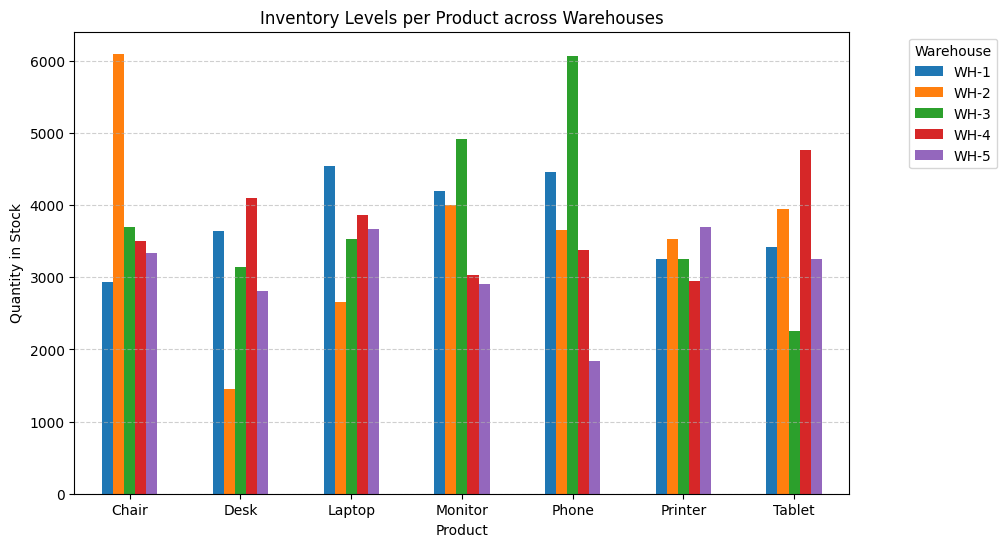

In [327]:
# bar chart
ProductInWerehouse.plot(kind='bar', figsize=(10, 6))
plt.title('Inventory Levels per Product across Warehouses')
plt.ylabel('Quantity in Stock')
plt.xlabel('Product')
plt.xticks(rotation=0)
plt.legend(title="Warehouse",bbox_to_anchor=(1.2,1))
plt.grid(axis='y', linestyle='--',alpha=0.6)

In [328]:

# Calculate Reorder Value
df["Reorder_alerts"] = df["ReorderPoint"] - df["QuantityInStock"]
# Create overstock df where product is overstock by 50 or more 
overstock_df = df[df["Reorder_alerts"] < -50]


In [329]:
# Which warehouse has more overstocks:
warehouse_overstock_count = (
    overstock_df.groupby("StorageLocation")["ProductID"]
    .count()
    .sort_values(ascending=False)
)
print("Overstocked products per warehouse:\n", warehouse_overstock_count)

Overstocked products per warehouse:
 StorageLocation
WH-3    82
WH-1    78
WH-4    76
WH-2    73
WH-5    64
Name: ProductID, dtype: int64


In [330]:
# Products overstocked in 3+ warehouses:
# df.head()
product_wh_spread = (
    overstock_df.groupby("ProductName")["StorageLocation"]
    .nunique()
    .sort_values(ascending=False)
)
products_3plus_wh = product_wh_spread[product_wh_spread >= 3]
print("Products overstocked in 3+ warehouses:\n", products_3plus_wh)

Products overstocked in 3+ warehouses:
 ProductName
Chair      5
Desk       5
Laptop     5
Monitor    5
Phone      5
Printer    5
Tablet     5
Name: StorageLocation, dtype: int64


In [331]:
# Which warehouse has which product overstocked:
warehouse_product_overstock = (
    overstock_df.groupby(["StorageLocation", "ProductName"])["ProductID"]
    .count()
    .reset_index(name="OverstockCount")
    .sort_values(["StorageLocation", "OverstockCount"], ascending=[True, False])
)
print(warehouse_product_overstock)

   StorageLocation ProductName  OverstockCount
2             WH-1      Laptop              15
4             WH-1       Phone              13
3             WH-1     Monitor              11
5             WH-1     Printer              11
1             WH-1        Desk              10
0             WH-1       Chair               9
6             WH-1      Tablet               9
7             WH-2       Chair              17
10            WH-2     Monitor              13
11            WH-2       Phone              11
12            WH-2     Printer              10
13            WH-2      Tablet              10
9             WH-2      Laptop               7
8             WH-2        Desk               5
18            WH-3       Phone              19
17            WH-3     Monitor              14
14            WH-3       Chair              11
15            WH-3        Desk              11
16            WH-3      Laptop              10
19            WH-3     Printer               9
20           

In [332]:
# def reorder(r):
#     if r < -50:
#         return f"Overstock {abs(r)} stocks left for reorder"
#     elif r >= -50 and r< 0 :
#         return f"Ready to order {abs(r)} stocks left for reorder"
#     else:
#         return f"Need to order {abs(r)} stocks less for reorder"

'''
create a function that says is product need to reorder or not
'''

def reorder(r):
    if r < -50:
        return f"Overstock "
    elif r >= -50 and r< 0 :
        return f"Ready to order "
    else:
        return f"Need to order "

In [333]:
# apply the function
df["StockStatus"] = df["Reorder_alerts"].apply(reorder)
df.head()

,ProductID,ProductName,QuantityInStock,ReorderPoint,Supplier,SupplierContact,LeadTime,StorageLocation,UnitCost,Reorder_alerts,StockStatus
0,P98420,Monitor,97,81,Global Parts,global parts@example.com,17,WH-5,174.13,-16,Ready to order
1,P70372,Monitor,229,32,SupplyCo,supplyco@example.com,19,WH-4,91.07,-197,Overstock
2,P54851,Laptop,15,72,Global Parts,global parts@example.com,13,WH-5,179.93,57,Need to order
3,P89338,Tablet,35,56,Global Parts,global parts@example.com,21,WH-2,159.55,21,Need to order
4,P76449,Chair,442,64,DirectGoods,directgoods@example.com,8,WH-4,2.02,-378,Overstock


In [334]:
# Specific product stock report 
def product_report(product_name):
    return df[df["ProductName"] == product_name][
        ["ProductID", "StorageLocation", "QuantityInStock",
         "ReorderPoint", "Reorder_alerts","StockStatus","Supplier", "LeadTime"]
    ].sort_values("StorageLocation")

product_report("Monitor")   # change product name to other products for info

,ProductID,StorageLocation,QuantityInStock,ReorderPoint,Reorder_alerts,StockStatus,Supplier,LeadTime
492,P60419,WH-1,111,60,-51,Overstock,DirectGoods,12
221,P89769,WH-1,452,74,-378,Overstock,Global Parts,8
168,P15958,WH-1,38,22,-16,Ready to order,DirectGoods,15
253,P48568,WH-1,63,35,-28,Ready to order,Global Parts,11
256,P10033,WH-1,358,96,-262,Overstock,WarePlus,19
...,...,...,...,...,...,...,...,...
331,P81902,WH-5,386,67,-319,Overstock,WarePlus,10
117,P57921,WH-5,64,41,-23,Ready to order,DirectGoods,14
161,P50748,WH-5,13,96,83,Need to order,Global Parts,9
59,P15363,WH-5,219,41,-178,Overstock,SupplyCo,13


### Here ai used for code (i ask question and give logics what i want )

- which warehouse has more overstocks 
- which warehouse has which product is overstock 
- which product is overstock in 3 or more warehouse
- a specific product stock report in all warehouse  

code by ai without sharing data 

***Reorder Analysis***

In [335]:
# Filter products needing reorder
reorder_df = df[df["QuantityInStock"] < df["ReorderPoint"]]

# Show important columns
print(reorder_df[[
    "ProductID",
    "ProductName",
    "StorageLocation",
    "QuantityInStock",
    "ReorderPoint"
]])


    ProductID ProductName StorageLocation  QuantityInStock  ReorderPoint
2      P54851      Laptop            WH-5               15            72
3      P89338      Tablet            WH-2               35            56
8      P47947      Tablet            WH-3               54            99
14     P60361      Tablet            WH-1               16            70
25     P50133     Monitor            WH-3                1            55
..        ...         ...             ...              ...           ...
457    P20294        Desk            WH-2               87            91
459    P82334      Laptop            WH-2               63           100
462    P21813     Monitor            WH-3                3            57
483    P41997       Phone            WH-1               46            71
488    P21308        Desk            WH-2               51            73

[66 rows x 5 columns]


In [336]:
'''
write a python pandas code 
loop through unique warehouses in reorder_df and print
ProductID 
ProductName 
StorageLocation  
QuantityInStock  
ReorderPoint    
Supplier         
SupplierContact
'''

'\nwrite a python pandas code \nloop through unique warehouses in reorder_df and print\nProductID \nProductName \nStorageLocation  \nQuantityInStock  \nReorderPoint    \nSupplier         \nSupplierContact\n'

In [337]:
# Wrap unique() with sorted() to arrange warehouses alphabetically
for warehouse in sorted(reorder_df["StorageLocation"].unique()):
    print(f"\n{'='*50}")
    print(f"Warehouse: {warehouse}")
    print(f"{'='*50}")

    warehouse_data = reorder_df.loc[
        reorder_df["StorageLocation"] == warehouse,
        [
            "ProductID",
            "ProductName",
            "StorageLocation",
            "QuantityInStock",
            "ReorderPoint",
            "Supplier",
            "SupplierContact",
        ],
    ]

    print(warehouse_data.to_string(index=False))



Warehouse: WH-1
ProductID ProductName StorageLocation  QuantityInStock  ReorderPoint     Supplier          SupplierContact
   P60361      Tablet            WH-1               16            70  DirectGoods  directgoods@example.com
   P98261       Phone            WH-1               38            43     SupplyCo     supplyco@example.com
   P86149        Desk            WH-1               47            52     SupplyCo     supplyco@example.com
   P12102     Printer            WH-1               43            77  DirectGoods  directgoods@example.com
   P53506        Desk            WH-1               55            69  DirectGoods  directgoods@example.com
   P63170        Desk            WH-1               72            86 Global Parts global parts@example.com
   P73854       Phone            WH-1               57            67     WarePlus     wareplus@example.com
   P96499      Tablet            WH-1               37            49     SupplyCo     supplyco@example.com
   P53270        Des

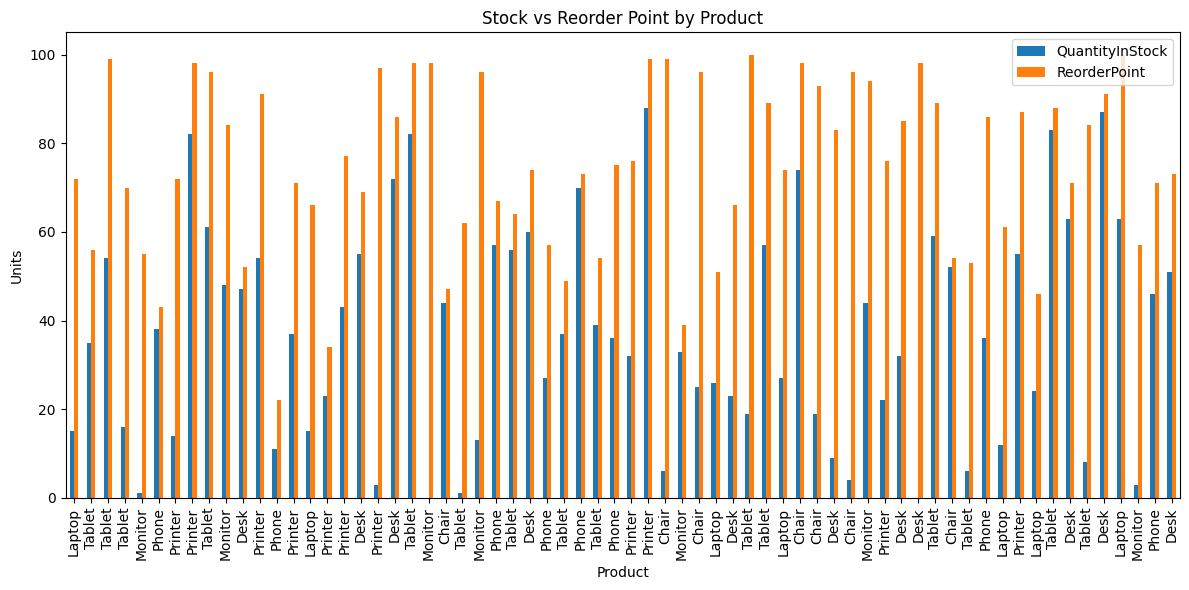

In [338]:
product_summary = reorder_df[
    ["ProductName", "QuantityInStock", "ReorderPoint"]
].set_index("ProductName")

product_summary.plot(
    kind="bar",
    figsize=(12, 6),
    title="Stock vs Reorder Point by Product"
)

plt.xlabel("Product")
plt.ylabel("Units")
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()

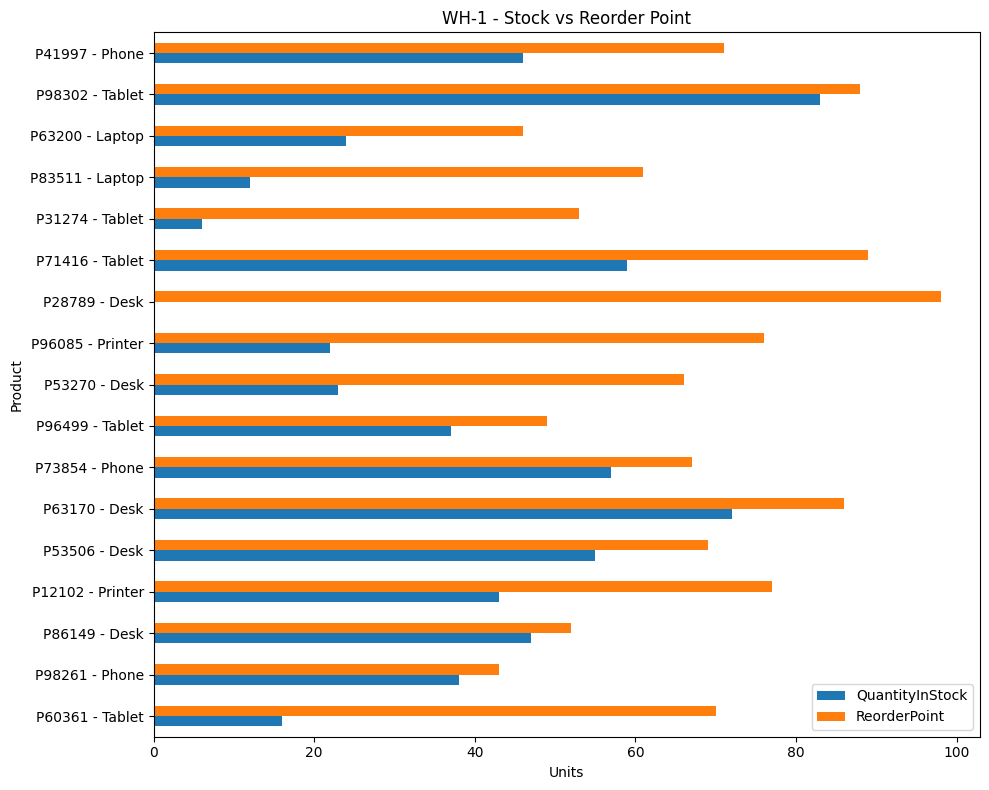

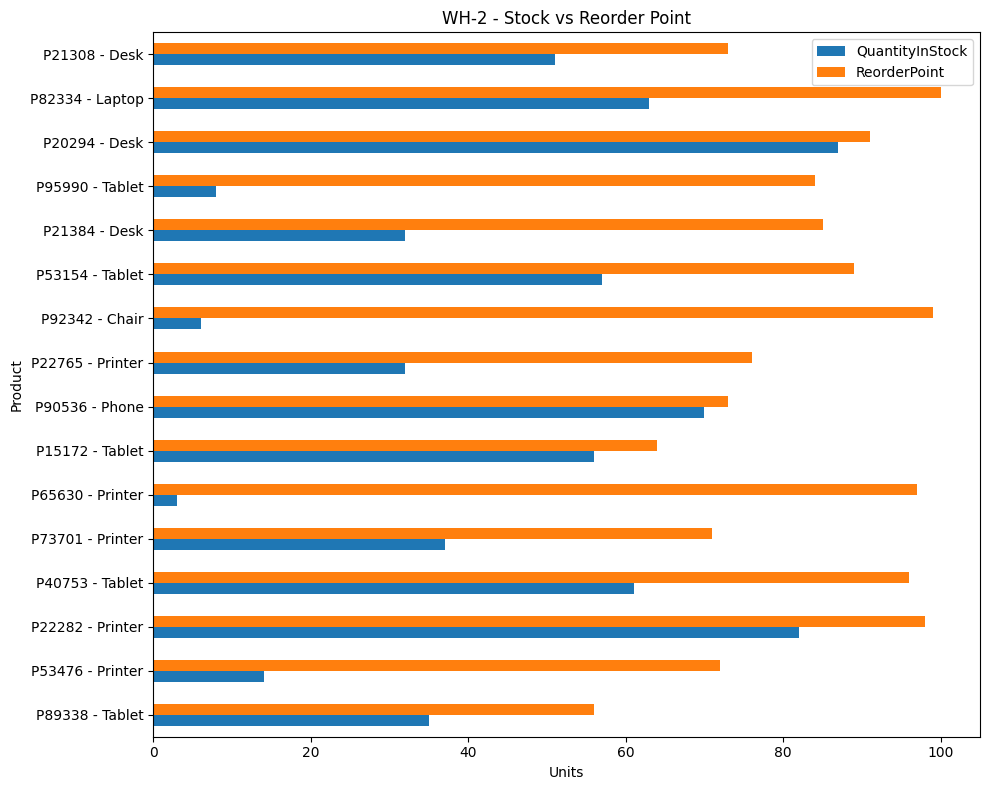

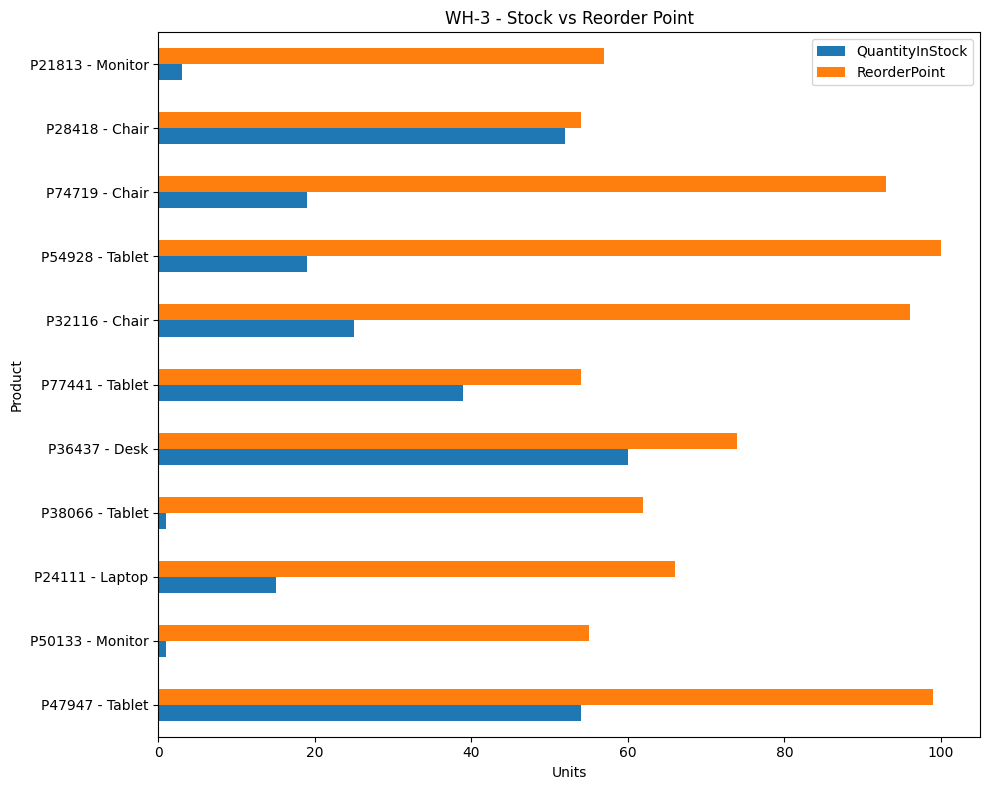

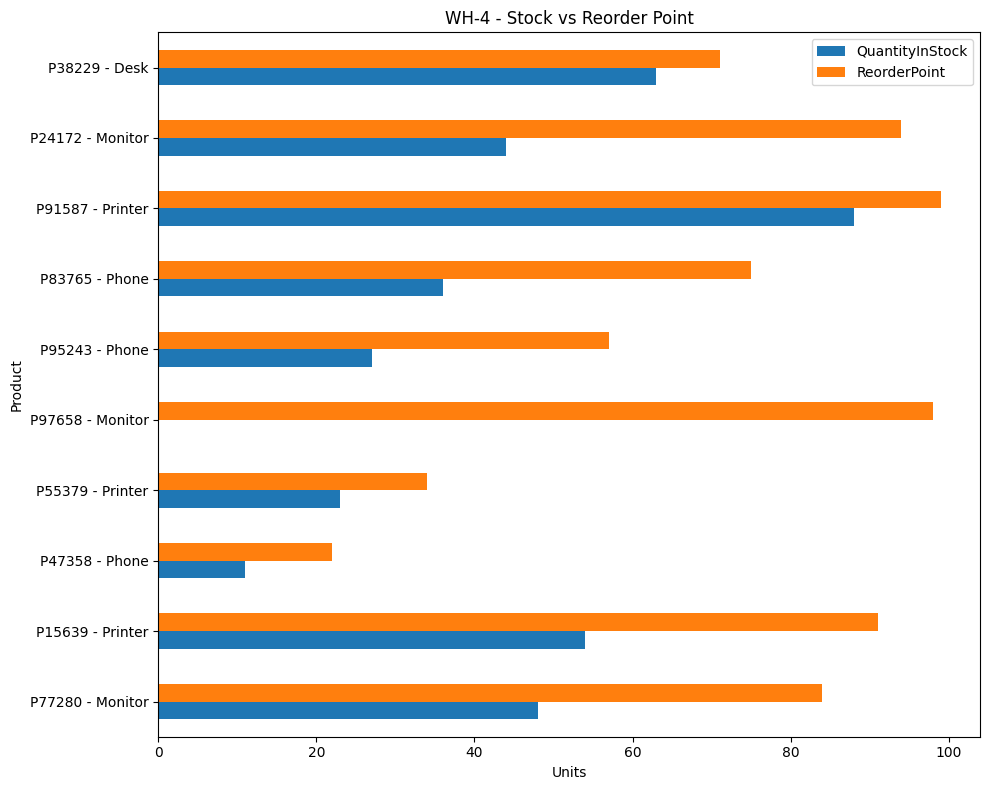

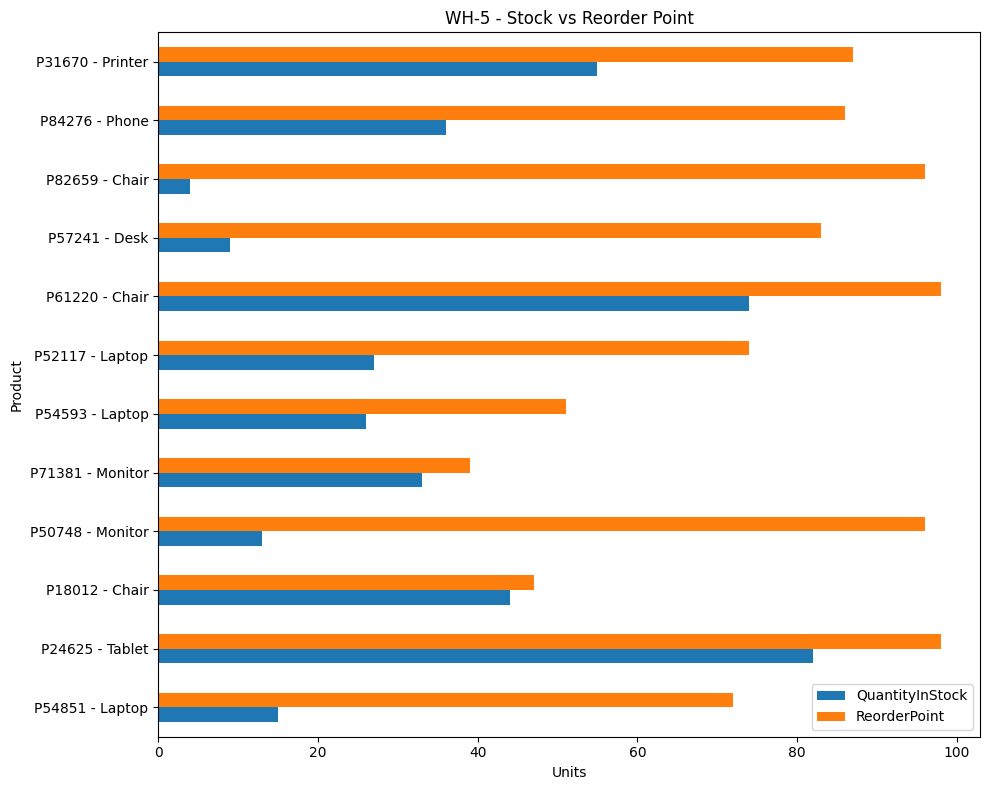

In [339]:
for warehouse in sorted(reorder_df["StorageLocation"].unique()):

    warehouse_data = reorder_df[
        reorder_df["StorageLocation"] == warehouse
    ].copy()

    warehouse_data["Product"] = (
        warehouse_data["ProductID"].astype(str)
        + " - "
        + warehouse_data["ProductName"]
    )

    chart_data = warehouse_data[
        ["Product", "QuantityInStock", "ReorderPoint"]
    ].set_index("Product")

    chart_data.plot(
        kind="barh",
        figsize=(10, 8),
        title=f"{warehouse} - Stock vs Reorder Point"
    )

    plt.xlabel("Units")
    plt.ylabel("Product")
    plt.tight_layout()
    plt.show()

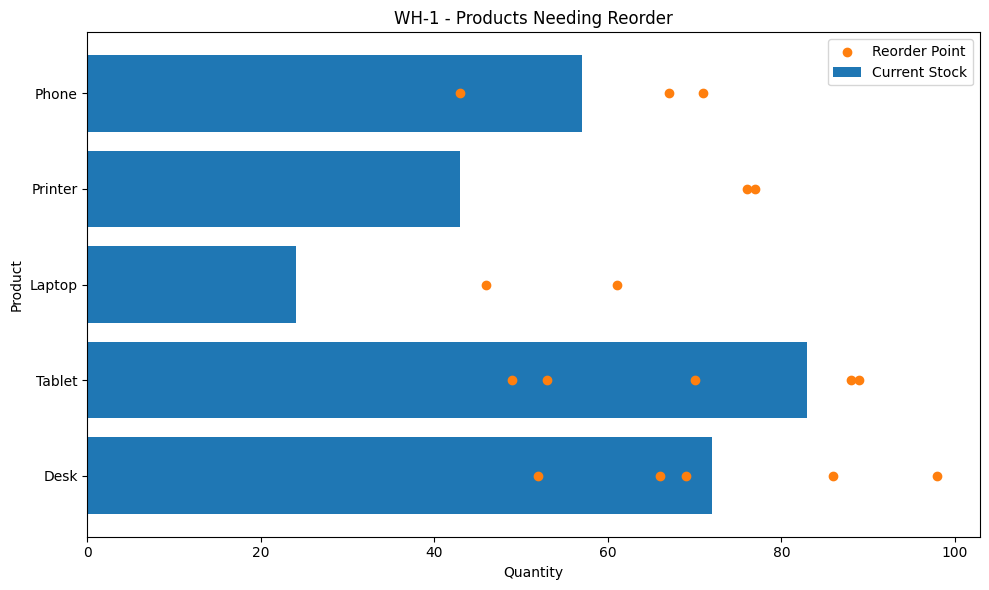

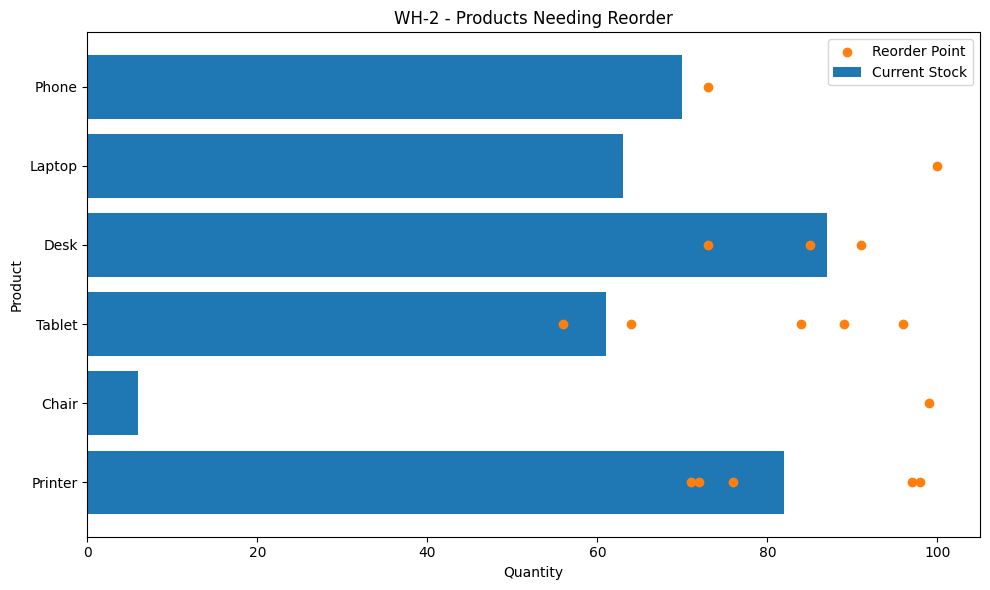

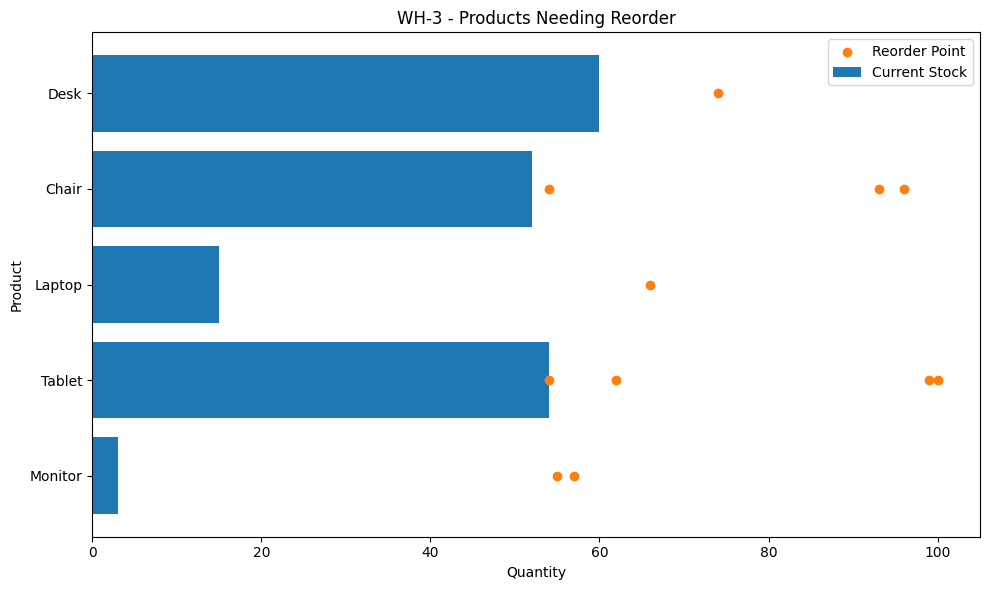

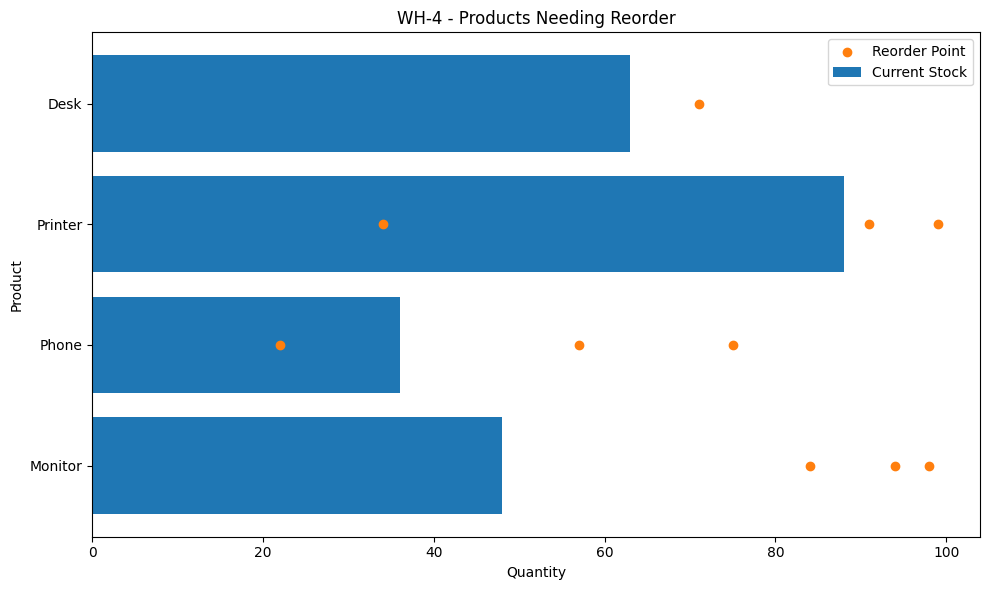

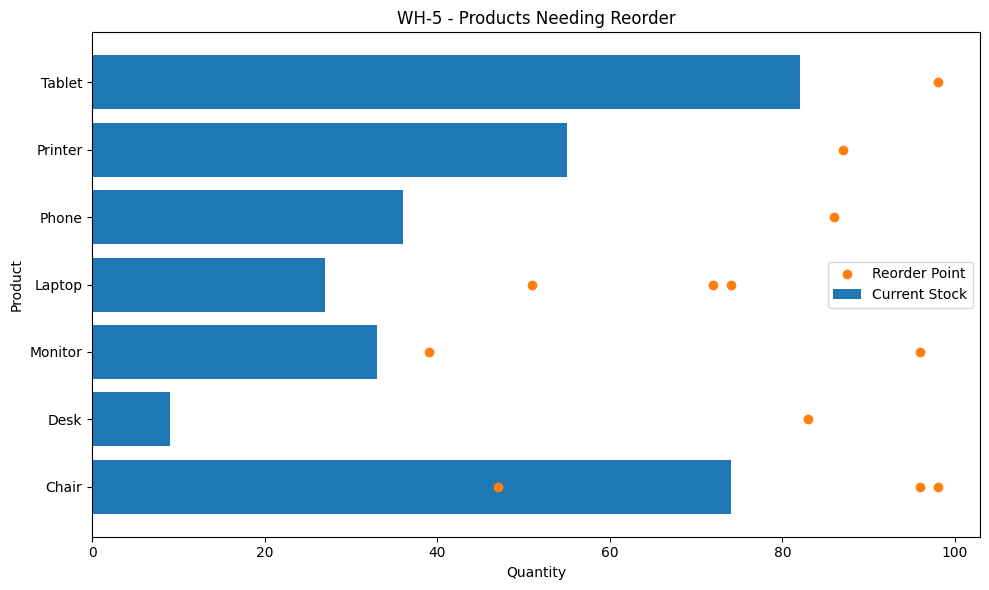

In [340]:

# Sort warehouse names
warehouses = sorted(
    reorder_df["StorageLocation"].unique()
)

# Create graph for each warehouse
for wh in warehouses:

    # Filter warehouse data
    wh_data = reorder_df[
        reorder_df["StorageLocation"] == wh
    ].copy()

    # Sort by lowest stock
    wh_data = wh_data.sort_values(
        by="QuantityInStock"
    )

    # Create figure
    plt.figure(figsize=(10,6))

    # Horizontal bars
    plt.barh(
        wh_data["ProductName"],
        wh_data["QuantityInStock"],
        label="Current Stock"
    )

    # Reorder point markers
    plt.scatter(
        wh_data["ReorderPoint"],
        wh_data["ProductName"],
        label="Reorder Point"
    )

    # Labels & title
    plt.title(f"{wh} - Products Needing Reorder")
    plt.xlabel("Quantity")
    plt.ylabel("Product")

    # Legend
    plt.legend()

    # Better spacing
    plt.tight_layout()

    # Show graph
    plt.show()

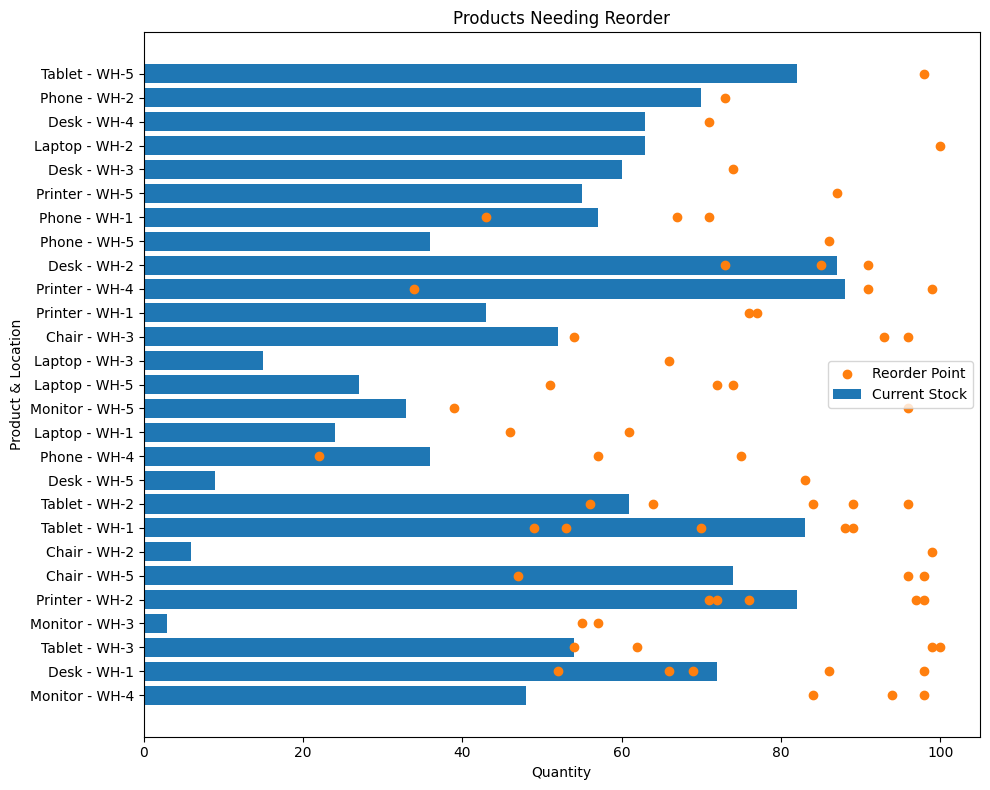

In [341]:

# Filter reorder products
reorder_df = df[df["QuantityInStock"] < df["ReorderPoint"]].copy()

# Create readable label
reorder_df["Label"] = (
    reorder_df["ProductName"] +
    " - " +
    reorder_df["StorageLocation"]
)

# Sort values
reorder_df = reorder_df.sort_values(
    by="QuantityInStock"
)

# Plot
plt.figure(figsize=(10,8))

# Current stock bars
plt.barh(
    reorder_df["Label"],
    reorder_df["QuantityInStock"],
    label="Current Stock"
)

# Reorder point dots
plt.scatter(
    reorder_df["ReorderPoint"],
    reorder_df["Label"],
    label="Reorder Point"
)

plt.xlabel("Quantity")
plt.ylabel("Product & Location")
plt.title("Products Needing Reorder")

plt.legend()

plt.tight_layout()
plt.show()

In [342]:
# Low stocks  products with supplier contacts groupd by wh
for warehouse in sorted(reorder_df["StorageLocation"].unique()):

    warehouse_data = reorder_df[
        reorder_df["StorageLocation"] == warehouse
    ].copy()

    warehouse_data["Shortfall"] = (
        warehouse_data["ReorderPoint"]
        - warehouse_data["QuantityInStock"]
    )

    print(f"\n{'='*60}")
    print(f"WAREHOUSE: {warehouse}")
    print(f"{'='*60}")

    for _, row in warehouse_data.iterrows():

        print(
            f"{row['ProductID']} | "
            f"{row['ProductName']} | "
            f"Shortfall: {row['Shortfall']} | "
            f"Supplier: {row['Supplier']} | "
            f"Contact: {row['SupplierContact']}"
        )


WAREHOUSE: WH-1
P28789 | Desk | Shortfall: 98 | Supplier: DirectGoods | Contact: directgoods@example.com
P31274 | Tablet | Shortfall: 47 | Supplier: Global Parts | Contact: global parts@example.com
P83511 | Laptop | Shortfall: 49 | Supplier: Global Parts | Contact: global parts@example.com
P60361 | Tablet | Shortfall: 54 | Supplier: DirectGoods | Contact: directgoods@example.com
P96085 | Printer | Shortfall: 54 | Supplier: WarePlus | Contact: wareplus@example.com
P53270 | Desk | Shortfall: 43 | Supplier: SupplyCo | Contact: supplyco@example.com
P63200 | Laptop | Shortfall: 22 | Supplier: Global Parts | Contact: global parts@example.com
P96499 | Tablet | Shortfall: 12 | Supplier: SupplyCo | Contact: supplyco@example.com
P98261 | Phone | Shortfall: 5 | Supplier: SupplyCo | Contact: supplyco@example.com
P12102 | Printer | Shortfall: 34 | Supplier: DirectGoods | Contact: directgoods@example.com
P41997 | Phone | Shortfall: 25 | Supplier: SupplyCo | Contact: supplyco@example.com
P86149 | De

***Supplier Analysis***

In [343]:
# Suppliers per product / products per supplier:
product_supplier_count = (
    df.groupby("ProductName")["Supplier"].nunique().sort_values(ascending=False)
)
print("Suppliers per product:\n", product_supplier_count)

supplier_product_count = (
    df.groupby("Supplier")["ProductName"].nunique().sort_values(ascending=False)
)
print("\nProducts per supplier:\n", supplier_product_count)

Suppliers per product:
 ProductName
Chair      4
Desk       4
Laptop     4
Monitor    4
Phone      4
Printer    4
Tablet     4
Name: Supplier, dtype: int64

Products per supplier:
 Supplier
DirectGoods     7
Global Parts    7
SupplyCo        7
WarePlus        7
Name: ProductName, dtype: int64


In [344]:
# Supplier with lowest/highest lead time:
supplier_leadtime = df.groupby("Supplier")["LeadTime"].mean().sort_values()
print(supplier_leadtime)
print(f"\nFastest supplier: {supplier_leadtime.idxmin()} ({supplier_leadtime.min():.1f} days avg)")
print(f"Slowest supplier: {supplier_leadtime.idxmax()} ({supplier_leadtime.max():.1f} days avg)")

Supplier
SupplyCo        11.333333
DirectGoods     11.780303
Global Parts    12.034783
WarePlus        12.946154
Name: LeadTime, dtype: float64

Fastest supplier: SupplyCo (11.3 days avg)
Slowest supplier: WarePlus (12.9 days avg)


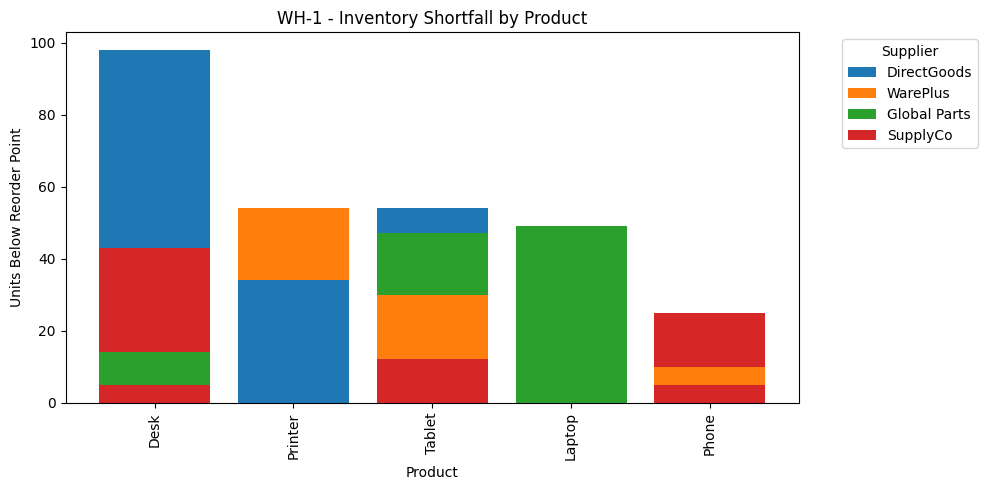

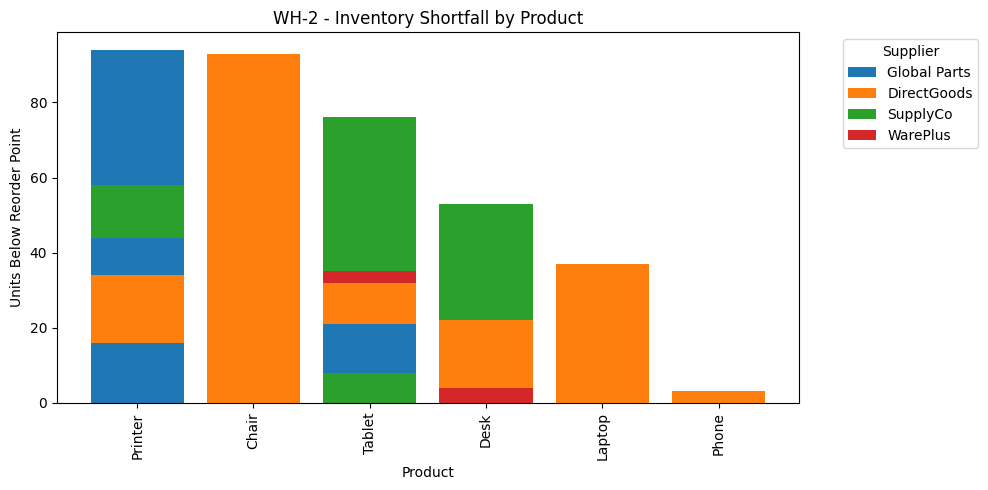

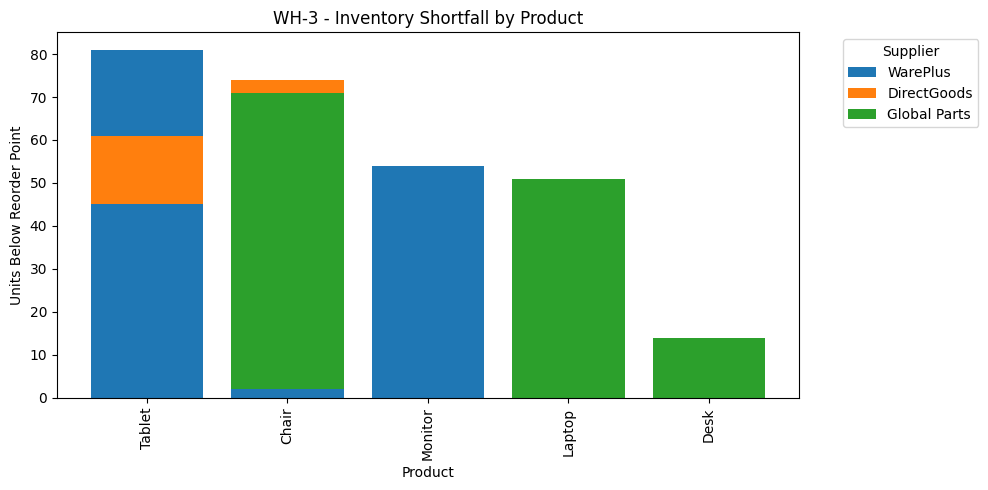

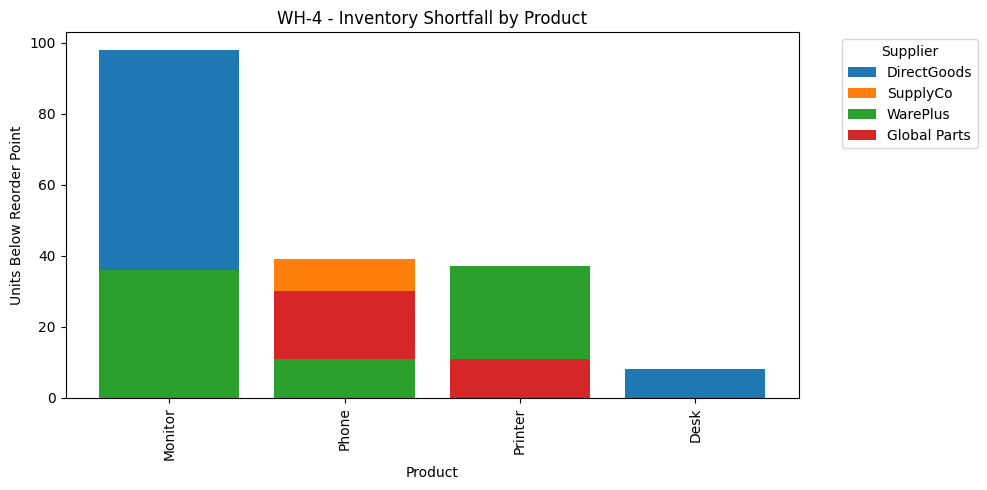

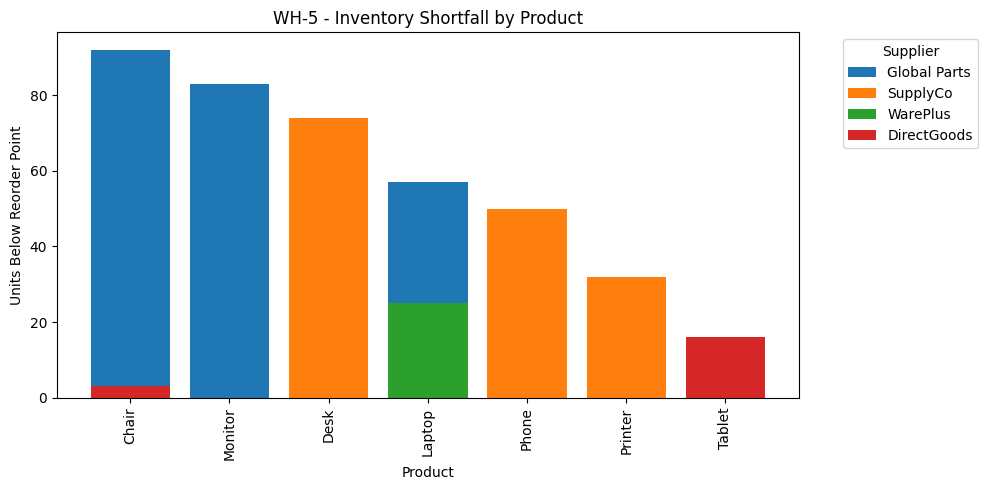

In [345]:

from matplotlib.patches import Patch

# Filter low-stock products
low_stock = reorder_df[
    reorder_df["QuantityInStock"] < reorder_df["ReorderPoint"]
].copy()

low_stock["Shortfall"] = (
    low_stock["ReorderPoint"]
    - low_stock["QuantityInStock"]
)

for warehouse in sorted(low_stock["StorageLocation"].unique()):

    warehouse_data = low_stock[
        low_stock["StorageLocation"] == warehouse
    ].sort_values("Shortfall", ascending=False)

    suppliers = warehouse_data["Supplier"].unique()
    colors = plt.cm.tab10.colors

    supplier_colors = {
        supplier: colors[i % len(colors)]
        for i, supplier in enumerate(suppliers)
    }

    bar_colors = [
        supplier_colors[supplier]
        for supplier in warehouse_data["Supplier"]
    ]

    plt.figure(figsize=(10, 5))

    plt.bar(
        warehouse_data["ProductName"],
        warehouse_data["Shortfall"],
        color=bar_colors
    )

    legend_elements = [
        Patch(facecolor=color, label=supplier)
        for supplier, color in supplier_colors.items()
    ]

    plt.legend(
        handles=legend_elements,
        title="Supplier",
        bbox_to_anchor=(1.05, 1),
        loc="upper left"
    )

    plt.title(f"{warehouse} - Inventory Shortfall by Product")
    plt.xlabel("Product")
    plt.ylabel("Units Below Reorder Point")
    plt.xticks(rotation=90)
    plt.tight_layout()
    plt.show()

In [346]:
# Low stock percentage of products in wh
low_stock = reorder_df[
    reorder_df["QuantityInStock"] < reorder_df["ReorderPoint"]
]

total_products = (
    df.groupby("StorageLocation")["ProductID"]
    .count()
)

low_stock_products = (
    low_stock.groupby("StorageLocation")["ProductID"]
    .count()
)

warehouse_summary = (
    total_products.to_frame("Total_Products")
    .join(
        low_stock_products.to_frame("Low_Stock_Products"),
        how="left"
    )
    .fillna(0)
)

warehouse_summary["Low_Stock_Products"] = (
    warehouse_summary["Low_Stock_Products"]
    .astype(int)
)

warehouse_summary["Low_Stock_Percentage"] = (
    warehouse_summary["Low_Stock_Products"]
    / warehouse_summary["Total_Products"]
    * 100
).round(2)

print(warehouse_summary.sort_values(
    "Low_Stock_Percentage",
    ascending=False
))

                 Total_Products  Low_Stock_Products  Low_Stock_Percentage
StorageLocation                                                          
WH-2                        101                  16                 15.84
WH-1                        109                  17                 15.60
WH-5                         85                  12                 14.12
WH-4                         95                  10                 10.53
WH-3                        110                  11                 10.00


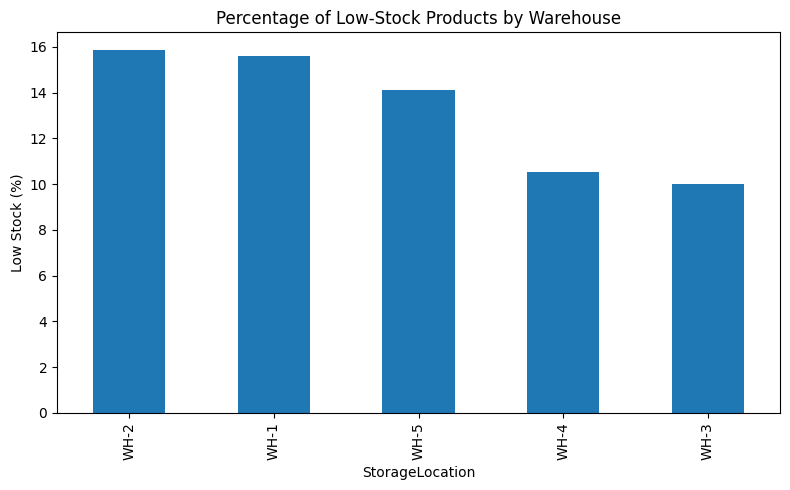

In [347]:
warehouse_summary["Low_Stock_Percentage"].sort_values(
    ascending=False
).plot(
    kind="bar",
    figsize=(8, 5),
    title="Percentage of Low-Stock Products by Warehouse"
)

plt.xlabel("StorageLocation")
plt.ylabel("Low Stock (%)")
plt.tight_layout()
plt.show()

In [348]:
# Supplier with shortages in all wh
reorder_df['Supplier'].value_counts()

Supplier
Global Parts    20
DirectGoods     17
WarePlus        15
SupplyCo        14
Name: count, dtype: int64

In [349]:
# Finds the supplier with the highest number of rows/shortages
most_shortages_supplier = reorder_df['Supplier'].value_counts().idxmax()
shortage_count = reorder_df['Supplier'].value_counts().max()


print(f"Supplier with most shortages: {most_shortages_supplier} ({shortage_count} events)")
print(f"Supplier with low shortages: {reorder_df['Supplier'].value_counts().idxmin()} ({reorder_df['Supplier'].value_counts().min()} events)")


Supplier with most shortages: Global Parts (20 events)
Supplier with low shortages: SupplyCo (14 events)


In [350]:
reorder_df

,ProductID,ProductName,QuantityInStock,ReorderPoint,Supplier,SupplierContact,LeadTime,StorageLocation,UnitCost,Reorder_alerts,StockStatus,Label
134,P97658,Monitor,0,98,DirectGoods,directgoods@example.com,16,WH-4,178.12,98,Need to order,Monitor - WH-4
387,P28789,Desk,0,98,DirectGoods,directgoods@example.com,16,WH-1,135.50,98,Need to order,Desk - WH-1
160,P38066,Tablet,1,62,DirectGoods,directgoods@example.com,7,WH-3,42.53,61,Need to order,Tablet - WH-3
25,P50133,Monitor,1,55,WarePlus,wareplus@example.com,12,WH-3,18.69,54,Need to order,Monitor - WH-3
462,P21813,Monitor,3,57,WarePlus,wareplus@example.com,18,WH-3,87.48,54,Need to order,Monitor - WH-3
...,...,...,...,...,...,...,...,...,...,...,...,...
44,P22282,Printer,82,98,Global Parts,global parts@example.com,8,WH-2,183.72,16,Need to order,Printer - WH-2
133,P24625,Tablet,82,98,DirectGoods,directgoods@example.com,7,WH-5,83.69,16,Need to order,Tablet - WH-5
445,P98302,Tablet,83,88,SupplyCo,supplyco@example.com,12,WH-1,135.39,5,Need to order,Tablet - WH-1
457,P20294,Desk,87,91,WarePlus,wareplus@example.com,18,WH-2,10.63,4,Need to order,Desk - WH-2


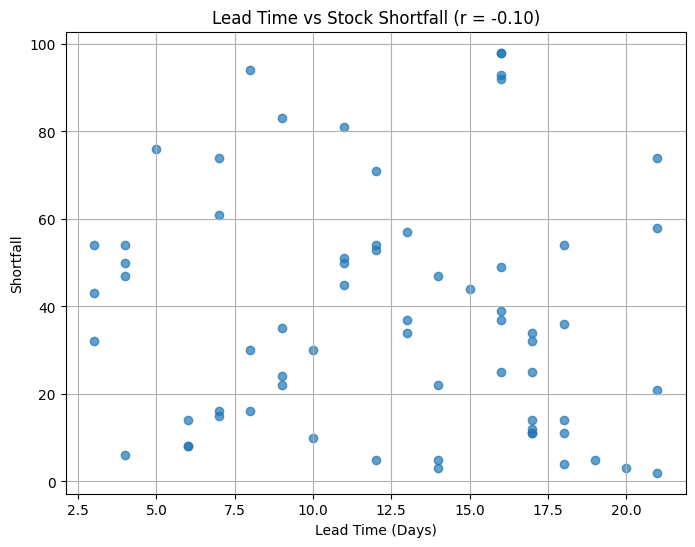

Correlation coefficient: -0.10


In [351]:
# Do products with longer supplier lead times have larger stock shortages?

lead_corr = reorder_df["LeadTime"].corr(reorder_df["Reorder_alerts"])

plt.figure(figsize=(8,6))
plt.scatter(reorder_df["LeadTime"], reorder_df["Reorder_alerts"], alpha=0.7)
plt.xlabel("Lead Time (Days)")
plt.ylabel("Shortfall")
plt.title(f"Lead Time vs Stock Shortfall (r = {lead_corr:.2f})")
plt.grid(True)
plt.show()

print(f"Correlation coefficient: {lead_corr:.2f}")

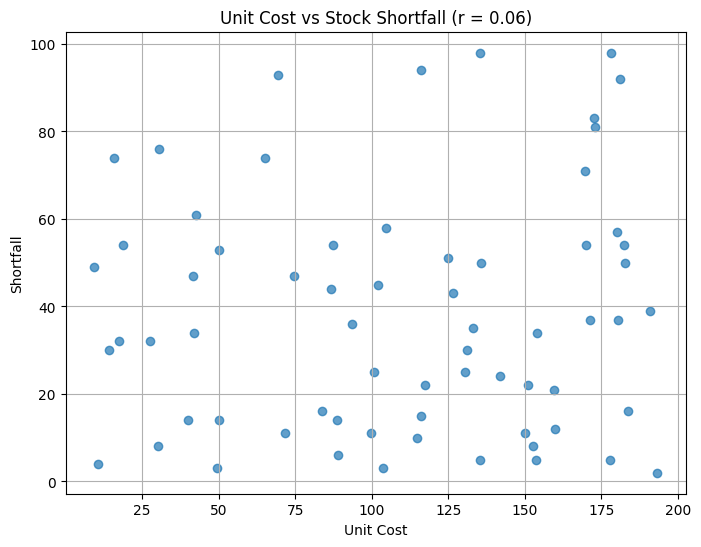

Correlation coefficient: 0.06


In [352]:
# Do products with higher unit price have larger stock shortages?
cost_corr = reorder_df["UnitCost"].corr(reorder_df["Reorder_alerts"])

plt.figure(figsize=(8,6))
plt.scatter(reorder_df["UnitCost"], reorder_df["Reorder_alerts"], alpha=0.7)
plt.xlabel("Unit Cost")
plt.ylabel("Shortfall")
plt.title(f"Unit Cost vs Stock Shortfall (r = {cost_corr:.2f})")
plt.grid(True)
plt.show()

print(f"Correlation coefficient: {cost_corr:.2f}")

In [353]:
# Overstock Counts
df_ovestock = df[df['Reorder_alerts'] < -50]
df_ovestock
print(f'Total {len(df_ovestock)} product overstock')

Total 373 product overstock
